# Getting started with `ggrepel_py`

Python port of R's [`ggrepel`](https://ggrepel.slowkow.com/) (version 0.9.8.9999). This notebook mirrors `vignettes/ggrepel.Rmd` from the R package.

`ggrepel_py` provides two `ggplot2_py` geoms that repel overlapping text labels:

- `geom_text_repel()`
- `geom_label_repel()`

Text labels repel away from each other, away from data points, and away from edges of the plotting area (panel).

In [1]:
from ggplot2_py import ggplot, aes, geom_point, geom_text, labs, theme_classic
from ggrepel_py import geom_text_repel, geom_label_repel
from ggrepel_py.data import load_mtcars

mtcars = load_mtcars()
mtcars.head()

,car,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## Compare `geom_text()` and `geom_text_repel()`

The canonical ggrepel example: label a subset of mtcars and compare the plain
text geom against the repelling version.

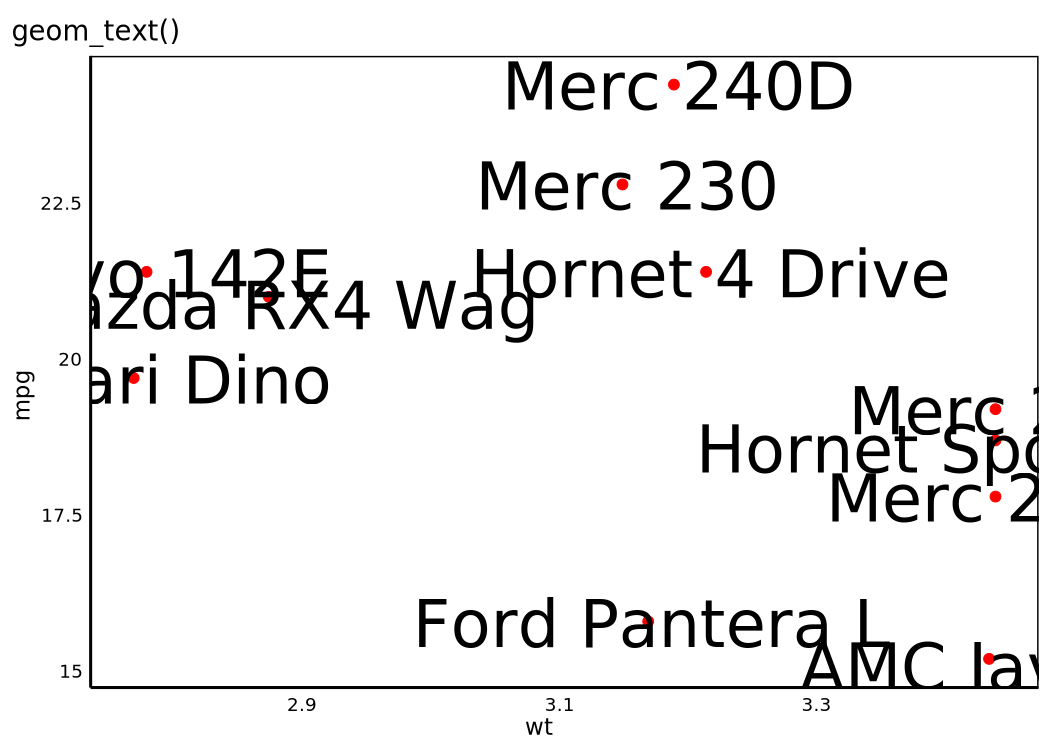

In [2]:
dat = mtcars[(mtcars['wt'] > 2.75) & (mtcars['wt'] < 3.45)].copy()
dat['car'] = dat['car']  # already present in load_mtcars output

p_base = (ggplot(dat, aes(x='wt', y='mpg', label='car'))
          + geom_point(color='red')
          + theme_classic())

p_plain = p_base + geom_text() + labs(title='geom_text()')
p_plain

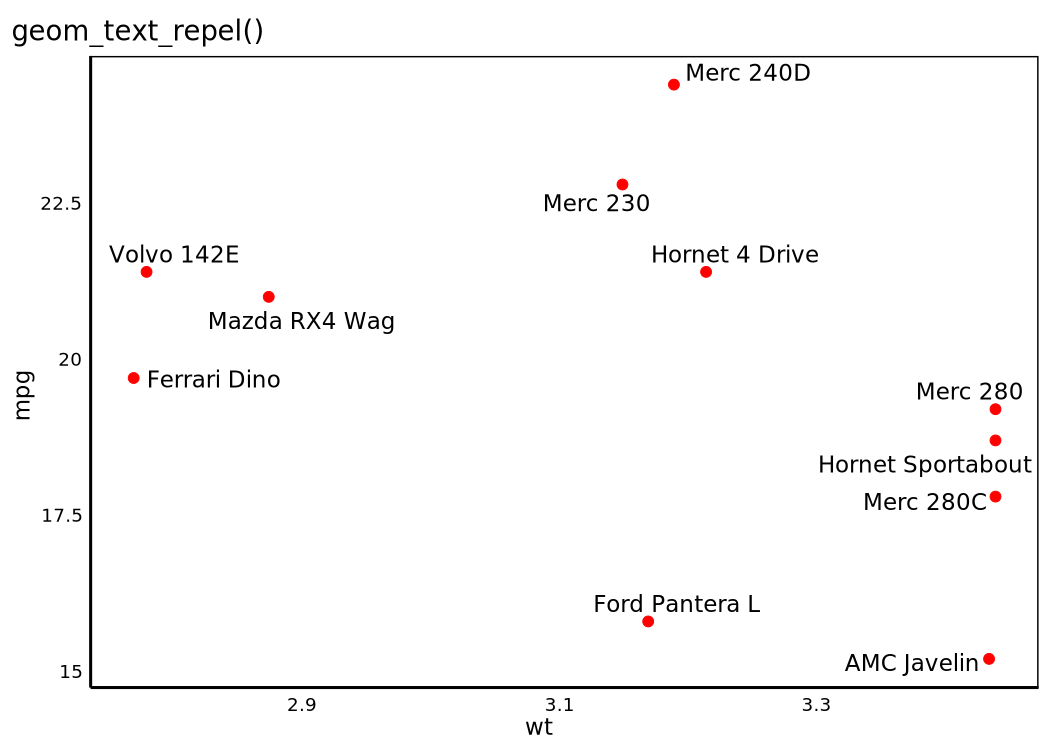

In [3]:
p_repel = p_base + geom_text_repel(seed=42) + labs(title='geom_text_repel()')
p_repel

## Key options

ggrepel_py preserves the R API but uses `snake_case` aesthetics and arguments:

| R option | Python argument | Description |
|---|---|---|
| `seed`                | `seed`                | Seed for reproducible layout (None = random) |
| `force`               | `force`               | Force of repulsion between overlapping labels |
| `force_pull`          | `force_pull`          | Force attracting each label to its data point |
| `direction`           | `direction`           | `"both"` (default), `"x"`, or `"y"` |
| `max.time`            | `max_time`            | Seconds before giving up on resolving overlaps |
| `max.iter`            | `max_iter`            | Maximum solver iterations |
| `max.overlaps`        | `max_overlaps`        | Drop labels that still overlap too many things |
| `nudge_x`, `nudge_y`  | `nudge_x`, `nudge_y`  | Initial offset applied to each label |
| `box.padding`         | `box_padding`         | Padding around the label box |
| `point.padding`       | `point_padding`       | Padding around the labeled data point |
| `min.segment.length`  | `min_segment_length`  | Skip the line segment if it is shorter than this |
| `arrow`               | `arrow`               | Pass a `grid.arrow()` to draw arrow heads |

Aesthetic names like `segment.colour`, `bg.colour`, `point.size` use snake
case too: `segment_colour`, `bg_colour`, `point_size`.

## `geom_label_repel()`

Same behavior, but with a rounded rectangle around each label.

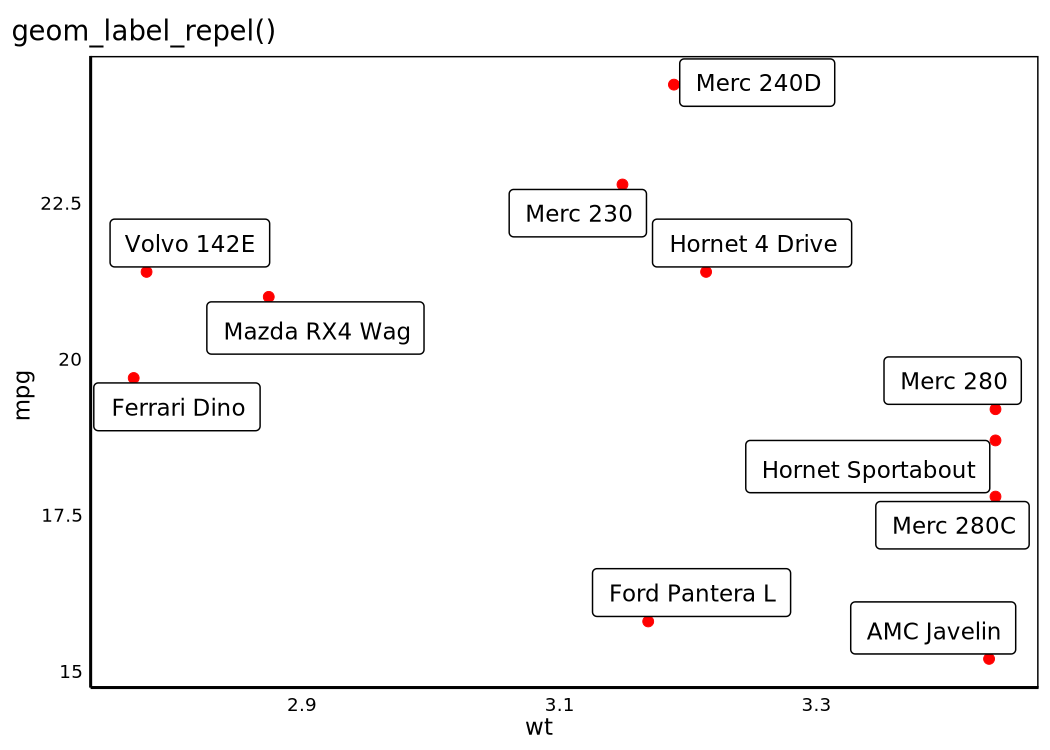

In [4]:
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_label_repel(seed=42, box_padding=0.35)
 + theme_classic()
 + labs(title='geom_label_repel()'))

## Deterministic layouts

Pass a `seed=` to make the output reproducible. Leaving it `None` uses a
fresh random state each call (matching R's default behavior).

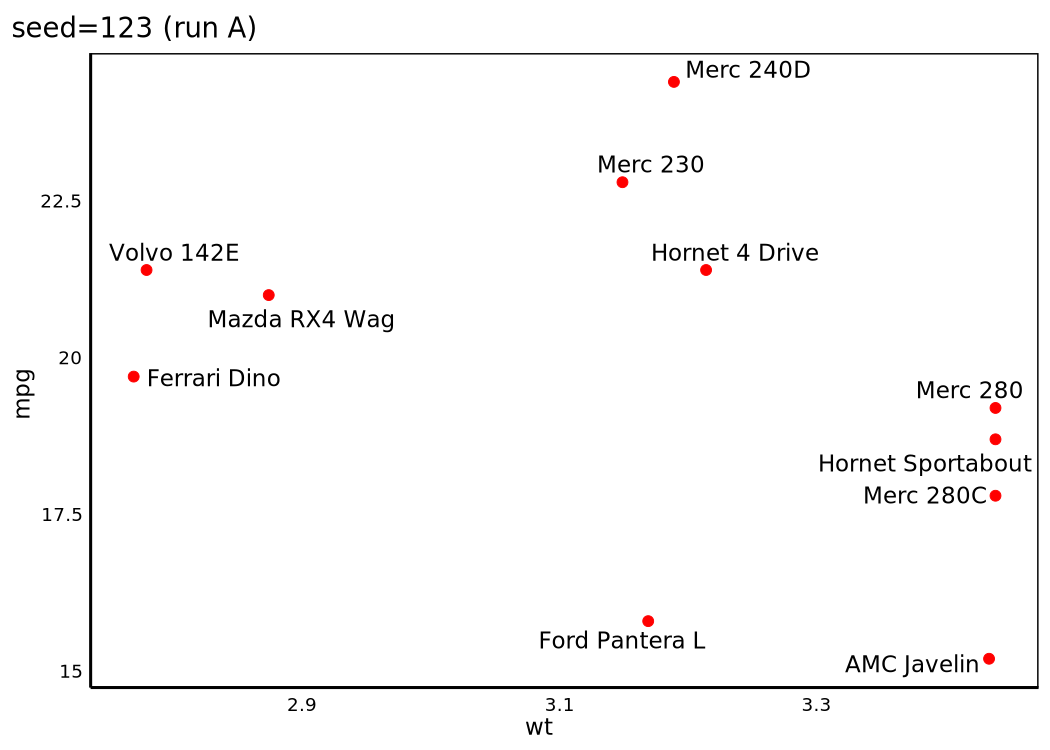

In [5]:
# Same seed => same layout on every run.
p1 = (ggplot(dat, aes(x='wt', y='mpg', label='car'))
      + geom_point(color='red')
      + geom_text_repel(seed=123)
      + theme_classic()
      + labs(title='seed=123 (run A)'))
p1

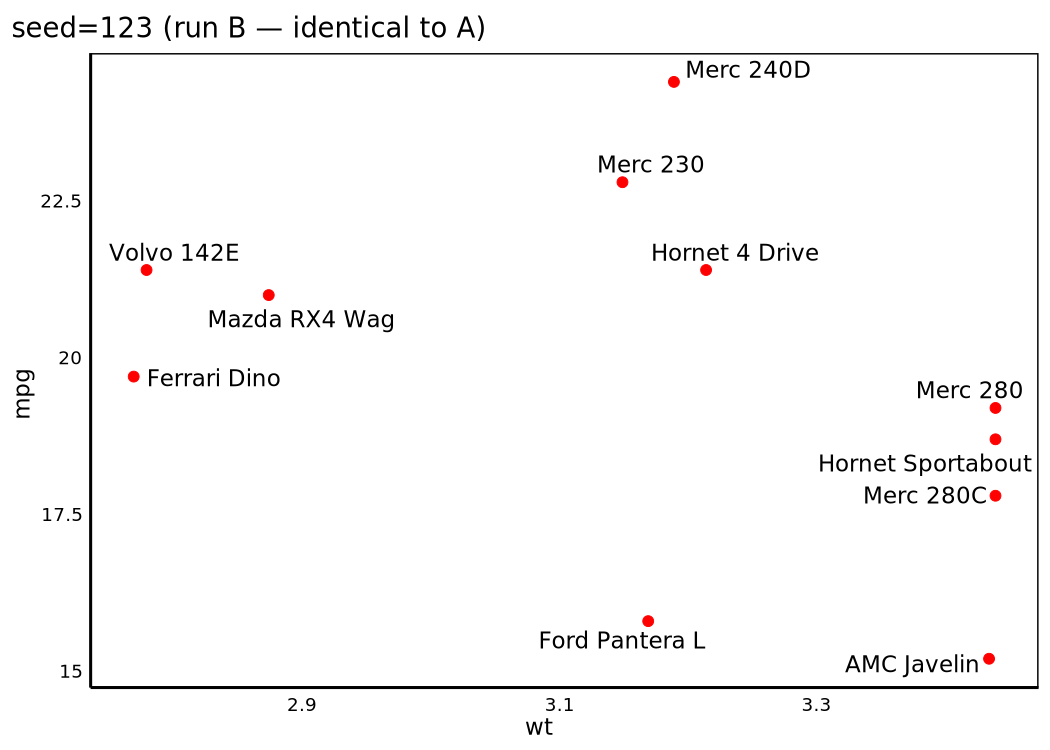

In [6]:
p2 = (ggplot(dat, aes(x='wt', y='mpg', label='car'))
      + geom_point(color='red')
      + geom_text_repel(seed=123)
      + theme_classic()
      + labs(title='seed=123 (run B — identical to A)'))
p2

## Next steps

- See `examples_v2.ipynb` for more advanced features (hidden labels, stacked points, segment styling, `nudge_x`/`nudge_y`).